# Tag Alterations — Figures

This notebook starts with the same dataset loading and cleaning as `quantitative.ipynb`, then reproduces all figures from `analyze_tags.ipynb`.

## 1. Setup

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import pickle
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df_all = pd.read_pickle("../data/tags_alteration_full_2025-10_dm.pkl")

In [3]:
df = df_all[df_all['status'] != 'non-legit'].copy()
df = df[df['old_snap_timestamp'] >= pd.Timestamp('2016-02-23')]

print(f"Total alterations: {len(df_all):_}")
print(f"Alterations used (excluding non-legit): {len(df):_}")
print(f"Non-legit filtered out: {len(df_all) - len(df):_}")

Total alterations: 15_166_153
Alterations used (excluding non-legit): 10_171_046
Non-legit filtered out: 4_995_107


In [4]:
analyzed_origins = 328_424_115 # more than 1 snapshot
skipped_origins = 74_425_148 # 1 snapshot or less
relevant_origins = 45_525_442 # at least 1 tag and 2 snapshots
total_tags = 3_197_620_436
total_l_tags = 1_417_510_761
total_a_tags = 1_780_109_675
unknown_branch = 819

In [5]:
annotated = df[df['type']=="annotated"]
lightweight = df[df['type']=="lightweight"]
unique_origins = df[['origin_url', 'stars']].drop_duplicates().reset_index(drop=True)

In [6]:
legit_moves = df[((df['creation_root_dir'].notna()) | (df['new_root_dir'].notna()))]
print(f'Amount of moves (direct or deletion->creation): {len(legit_moves):_}')

Amount of moves (direct or deletion->creation): 626_008


## 2. Derive Variables for Figures

In [7]:
# Temporal columns
df['snap_year'] = df['new_snap_timestamp'].dt.year
df['rev_year'] = df['new_rev_timestamp'].dt.year

In [8]:
# Platform classification
def categorize_platform(origin_url):
    if pd.isna(origin_url):
        return 'Other'
    if re.match(r'^https?://[^/]*github\.com', origin_url):
        return 'GitHub'
    elif re.match(r'^https?://[^/]*gitlab\.', origin_url):
        return 'GitLab'
    elif re.match(r'^https?://android\.googlesource\.com', origin_url):
        return 'Android'
    elif re.match(r'^https?://[^/]*bitbucket\.', origin_url):
        return 'BitBucket'
    elif re.match(r'^https?://[^/]*codeberg\.', origin_url):
        return 'Codeberg'
    elif re.match(r'^https?://[^/]*git\.sr\.ht', origin_url):
        return 'SourceHut'
    else:
        return 'Other'

df['platform'] = df['origin_url'].apply(categorize_platform)

platforms = ['GitHub', 'GitLab', 'Android', 'BitBucket', 'Codeberg', 'SourceHut', 'Other']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#95a5a6']

In [9]:
# Delta: minimal time between snapshots (in days)
df['delta'] = np.where(
    (df['new_snapshot_cpt'] - df['old_snapshot_cpt']) < 2,
    0,
    (df['min_delta'] - df['old_snap_timestamp']).dt.days
)

In [24]:
legit_moves = legit_moves.copy()
legit_moves['rev_time_diff_days'] = (
    legit_moves['new_rev_timestamp'] - legit_moves['old_rev_timestamp']
).dt.total_seconds() / (24 * 3600)

## 3. Figures

### 3.1 Tag Alterations Over Time (All, Yearly + Cumulative)

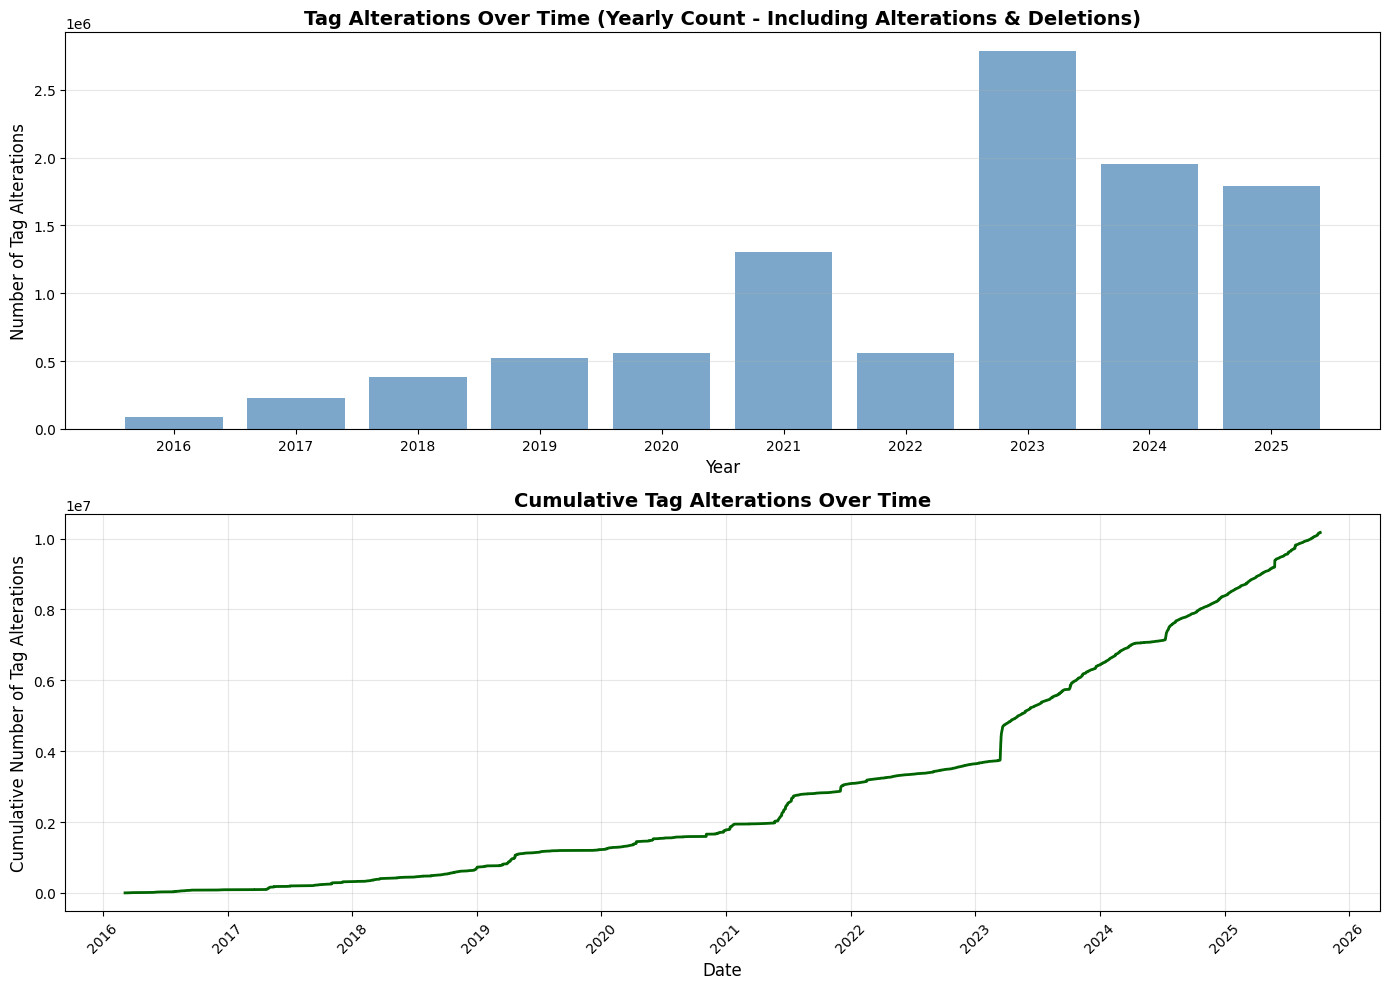

Total tag alterations plotted: 10_171_046
  - Tag Alterations: 626_008
  - Tag Deletions: 9_545_038
Date range: 2016-03-06 04:10:12 to 2025-10-08 14:44:16


In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

df_sorted = df.sort_values('new_snap_timestamp')
df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)

alterations_by_year = df.groupby('snap_year').size()

ax1.bar(alterations_by_year.index, alterations_by_year.values, width=0.8, alpha=0.7, color='steelblue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations', fontsize=12)
ax1.set_title('Tag Alterations Over Time (Yearly Count - Including Alterations & Deletions)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(alterations_by_year.index)

ax2.plot(df_sorted['new_snap_timestamp'], 
         df_sorted['cumulative_count'], 
         linewidth=2, color='darkgreen')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Alterations', fontsize=12)
ax2.set_title('Cumulative Tag Alterations Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Total tag alterations plotted: {len(df):_}")
print(f"  - Tag Alterations: {len(legit_moves):_}")
print(f"  - Tag Deletions: {len(df) - len(legit_moves):_}")
print(f"Date range: {df['new_snap_timestamp'].min()} to {df['new_snap_timestamp'].max()}")

### 3.2 Platform Comparison — Yearly and Cumulative (All)

/tmp/ipykernel_4020140/807604203.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/swh/scratch/rapaport/tags-alterations/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


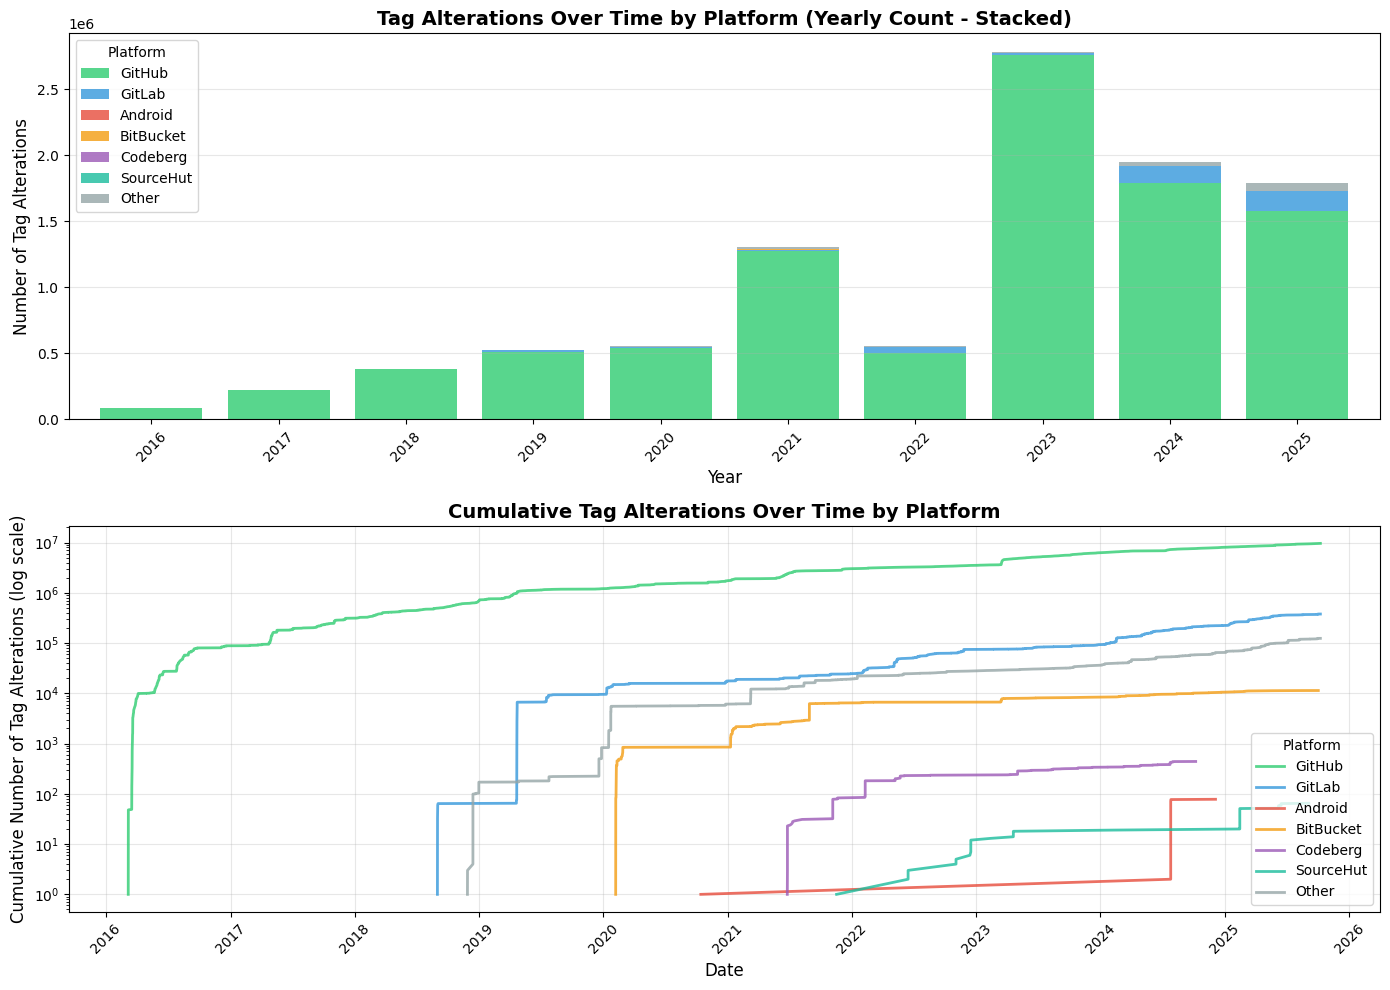

Platform distribution in the dataset:
  GitHub: 9655725 (94.9%)
  GitLab: 378996 (3.7%)
  Android: 78 (0.0%)
  BitBucket: 11391 (0.1%)
  Codeberg: 441 (0.0%)
  SourceHut: 65 (0.0%)
  Other: 124350 (1.2%)


In [13]:
# Platform comparison - Yearly and Cumulative Inconsistencies (All)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Yearly count by platform
platform_by_year = df.groupby(['snap_year', 'platform']).size().unstack(fill_value=0)
platform_by_year = platform_by_year.reindex(columns=platforms, fill_value=0)

platform_by_year.plot(kind='bar', stacked=True, ax=ax1, color=colors, alpha=0.8, width=0.8)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations', fontsize=12)
ax1.set_title('Tag Alterations Over Time by Platform (Yearly Count - Stacked)', fontsize=14, fontweight='bold')
ax1.legend(title='Platform', fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Cumulative count by platform
for i, platform in enumerate(platforms):
    platform_df = df[df['platform'] == platform].sort_values('new_snap_timestamp')
    platform_df['cumulative_count'] = range(1, len(platform_df) + 1)
    if len(platform_df) > 0:
        ax2.plot(platform_df['new_snap_timestamp'], 
                 platform_df['cumulative_count'], 
                 linewidth=2, color=colors[i], label=platform, alpha=0.8)

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Alterations (log scale)', fontsize=12)
ax2.set_title('Cumulative Tag Alterations Over Time by Platform', fontsize=14, fontweight='bold')
ax2.legend(title='Platform', fontsize=10)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Platform distribution in the dataset:")
for platform in platforms:
    count = len(df[df['platform'] == platform])
    print(f"  {platform}: {count} ({100*count/len(df):.1f}%)")

### 3.3 Tag Moves Over Time (Yearly + Cumulative)

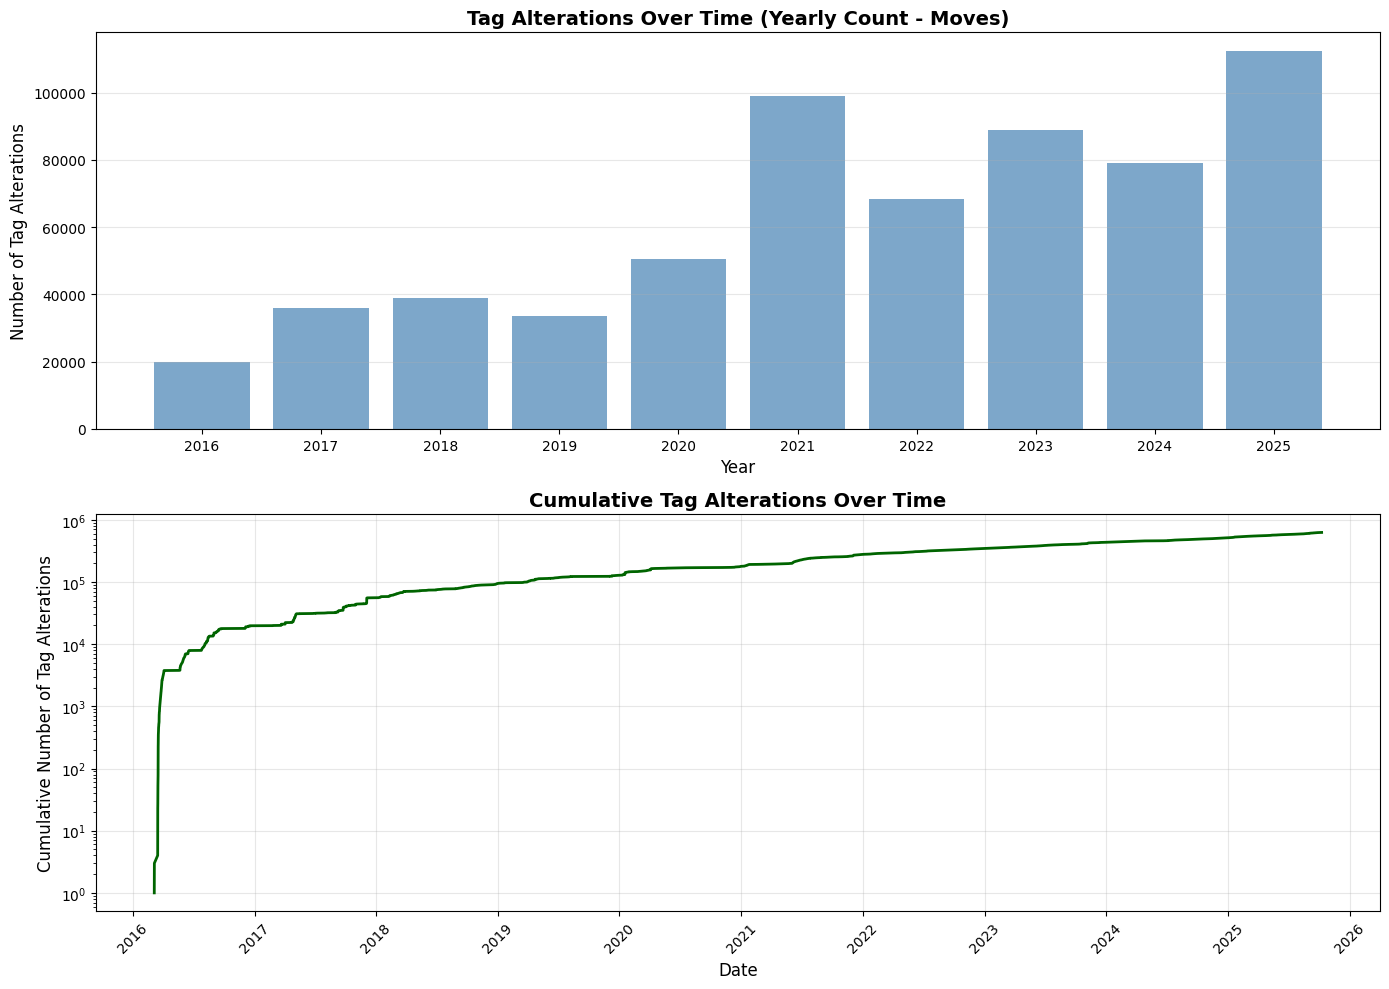

Total tag alterations plotted: 10171046
  - Tag Alterations: 626008
  - Tag Deletions: 9545038
Date range: 2016-03-06 04:10:12 to 2025-10-08 14:44:16


In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

df_sorted = legit_moves.sort_values('new_snap_timestamp')
df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)

alterations_by_year = legit_moves.groupby('snap_year').size()

ax1.bar(alterations_by_year.index, alterations_by_year.values, width=0.8, alpha=0.7, color='steelblue')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations', fontsize=12)
ax1.set_title('Tag Alterations Over Time (Yearly Count - Moves)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(alterations_by_year.index)

ax2.plot(df_sorted['new_snap_timestamp'], 
         df_sorted['cumulative_count'], 
         linewidth=2, color='darkgreen')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Alterations', fontsize=12)
ax2.set_title('Cumulative Tag Alterations Over Time', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Total tag alterations plotted: {len(df)}")
print(f"  - Tag Alterations: {len(legit_moves)}")
print(f"  - Tag Deletions: {len(df) - len(legit_moves)}")
print(f"Date range: {df['new_snap_timestamp'].min()} to {df['new_snap_timestamp'].max()}")

### 3.4 Platform Comparison — Yearly and Cumulative (Moves Only)

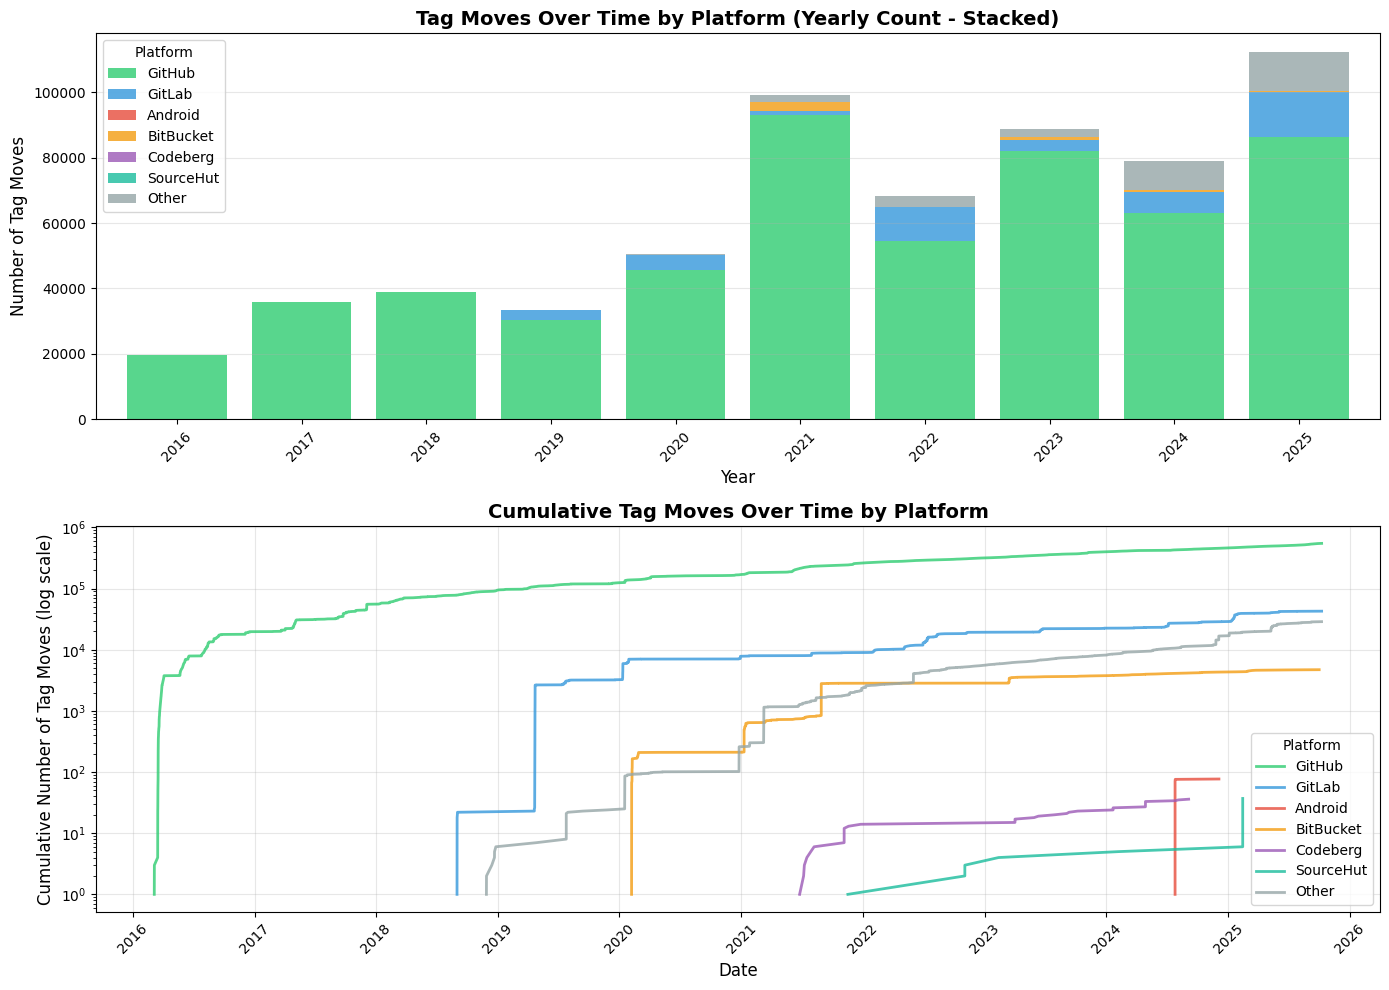

Platform distribution for tag moves:
  GitHub: 549523 (87.8%)
  GitLab: 42780 (6.8%)
  Android: 77 (0.0%)
  BitBucket: 4722 (0.8%)
  Codeberg: 36 (0.0%)
  SourceHut: 37 (0.0%)
  Other: 28833 (4.6%)


In [15]:
# Platform comparison - Yearly and Cumulative Moves (Alterations Only)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Yearly count by platform (alterations only)
platform_by_year_alt = legit_moves.groupby(['snap_year', 'platform']).size().unstack(fill_value=0)
platform_by_year_alt = platform_by_year_alt.reindex(columns=platforms, fill_value=0)

platform_by_year_alt.plot(kind='bar', stacked=True, ax=ax1, color=colors, alpha=0.8, width=0.8)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Tag Moves', fontsize=12)
ax1.set_title('Tag Moves Over Time by Platform (Yearly Count - Stacked)', fontsize=14, fontweight='bold')
ax1.legend(title='Platform', fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Cumulative count by platform (alterations only)
for i, platform in enumerate(platforms):
    platform_df = legit_moves[legit_moves['platform'] == platform].sort_values('new_snap_timestamp')
    platform_df['cumulative_count'] = range(1, len(platform_df) + 1)
    if len(platform_df) > 0:
        ax2.plot(platform_df['new_snap_timestamp'], 
                 platform_df['cumulative_count'], 
                 linewidth=2, color=colors[i], label=platform, alpha=0.8)

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Cumulative Number of Tag Moves (log scale)', fontsize=12)
ax2.set_title('Cumulative Tag Moves Over Time by Platform', fontsize=14, fontweight='bold')
ax2.legend(title='Platform', fontsize=10)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Platform distribution for tag moves:")
for platform in platforms:
    count = len(legit_moves[legit_moves['platform'] == platform])
    print(f"  {platform}: {count} ({100*count/len(legit_moves):.1f}%)")

### 3.5 Distribution of Time Between Alterations (All)

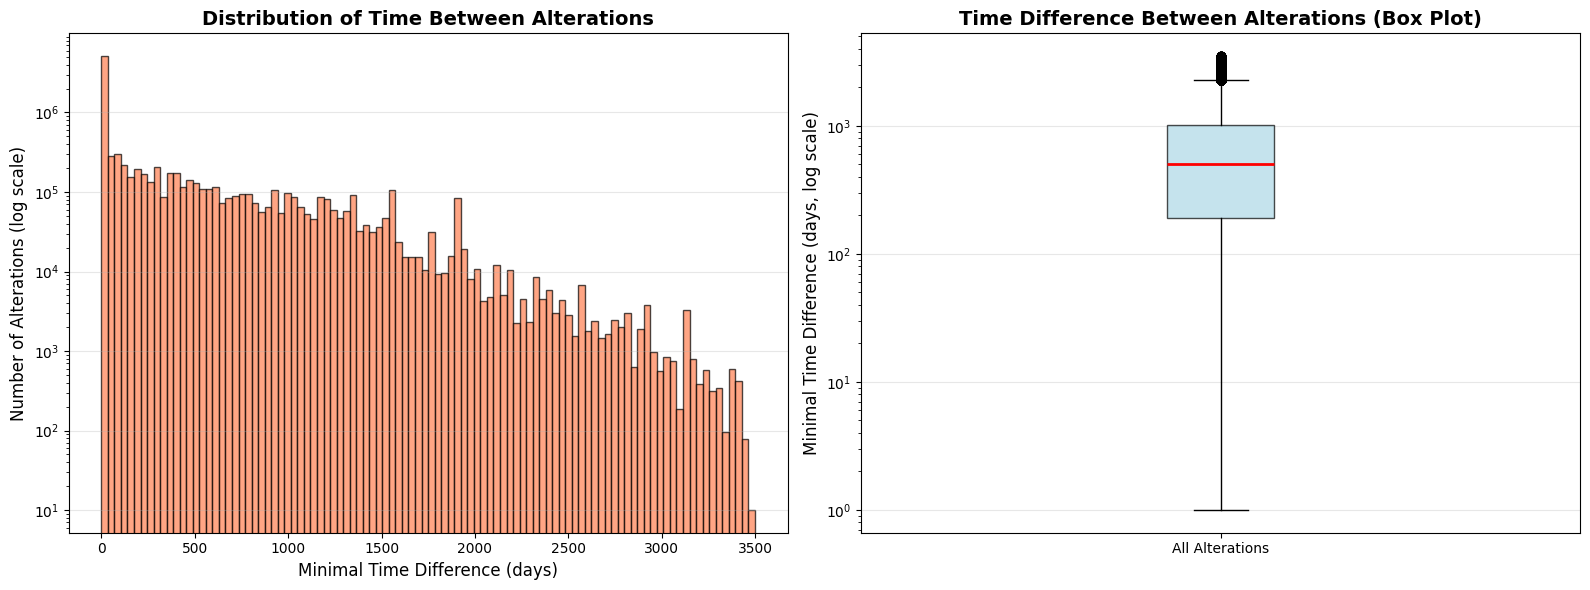

Time difference statistics:
  Mean: 347.13 days
  Median: 27.00 days
  Min: 0.00 days
  Max: 3498.00 days
  Std: 532.85 days


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

time_diffs_filtered = df['delta'].dropna()
ax1.hist(time_diffs_filtered, bins=100, alpha=0.7, color='coral', edgecolor='black')
ax1.set_xlabel('Minimal Time Difference (days)', fontsize=12)
ax1.set_ylabel('Number of Alterations (log scale)', fontsize=12)
ax1.set_title('Distribution of Time Between Alterations', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot([time_diffs_filtered[time_diffs_filtered > 0]], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Minimal Time Difference (days, log scale)', fontsize=12)
ax2.set_title('Time Difference Between Alterations (Box Plot)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(['All Alterations'])

plt.tight_layout()
plt.show()

print(f"Time difference statistics:")
print(f"  Mean: {time_diffs_filtered.mean():.2f} days")
print(f"  Median: {time_diffs_filtered.median():.2f} days")
print(f"  Min: {time_diffs_filtered.min():.2f} days")
print(f"  Max: {time_diffs_filtered.max():.2f} days")
print(f"  Std: {time_diffs_filtered.std():.2f} days")

### 3.6 Time Between Alterations by Platform (All)

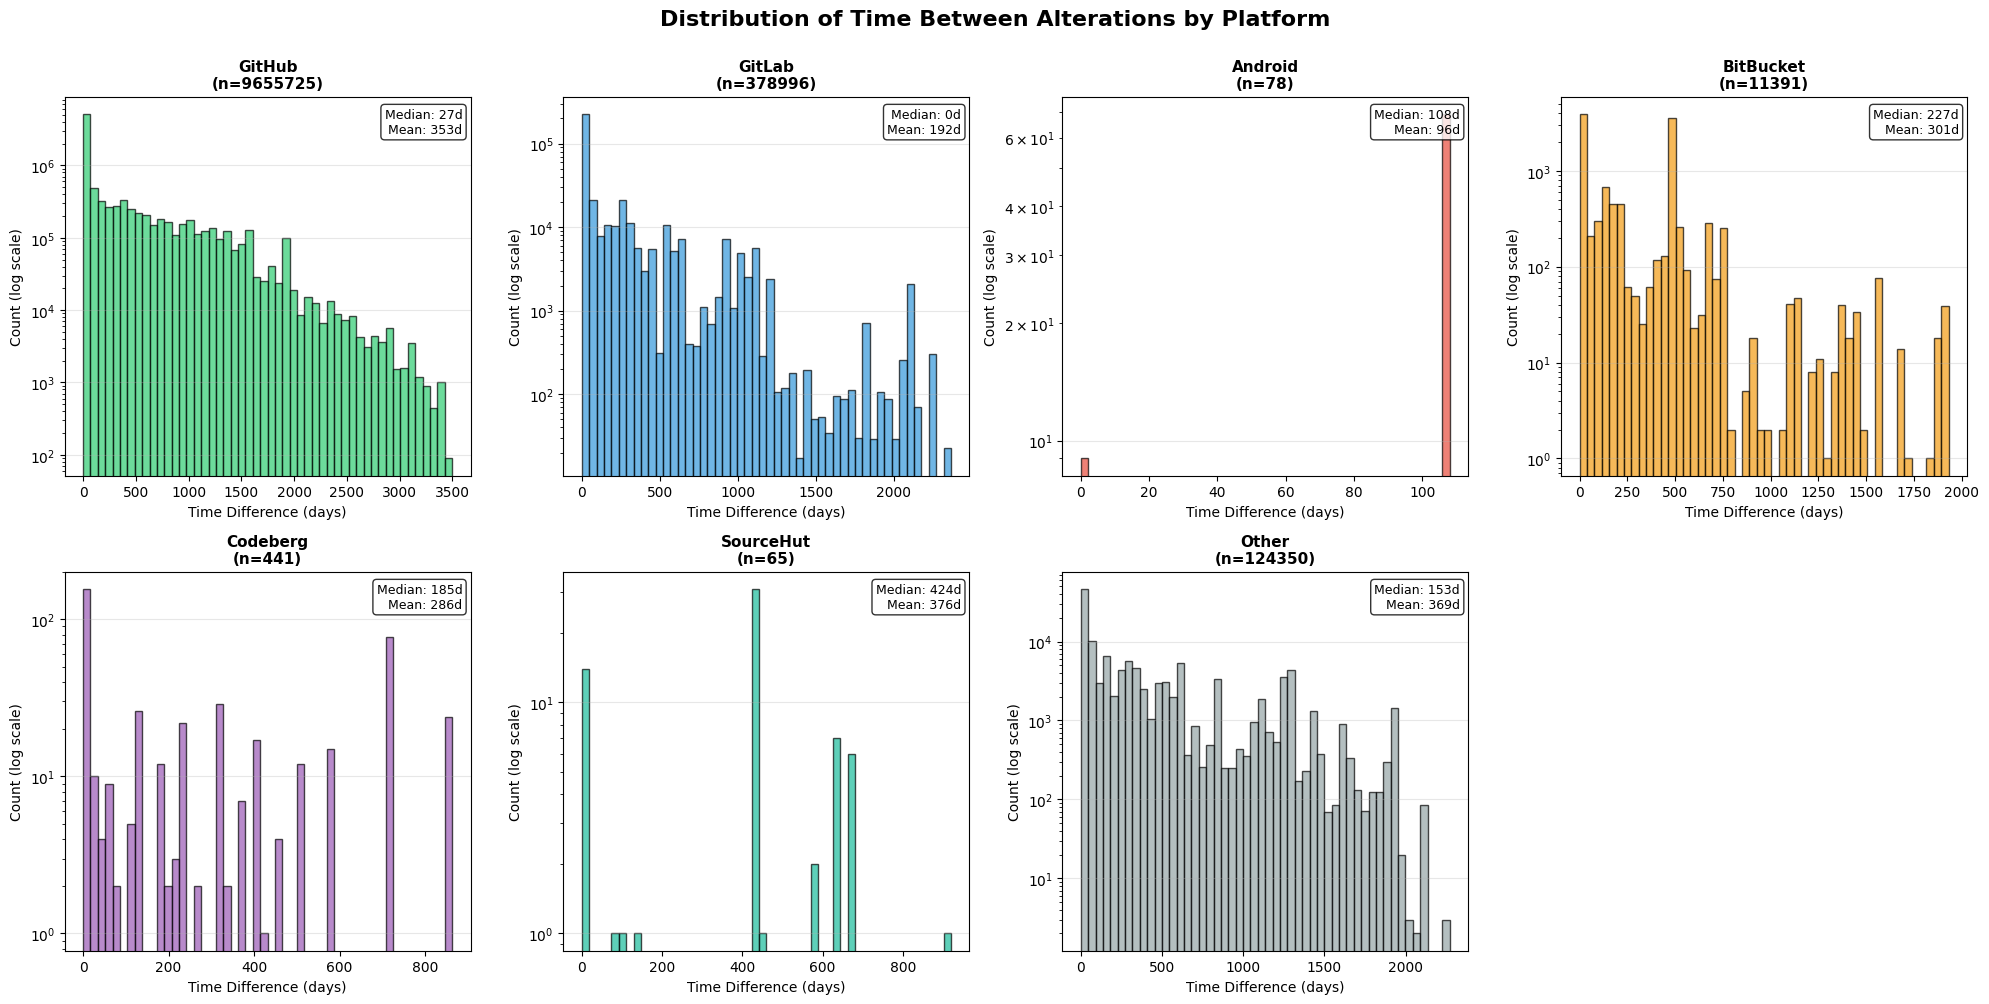

In [17]:
# Platform comparison - Time Between Alterations Distribution (All Inconsistencies)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, platform in enumerate(platforms):
    platform_df = df[df['platform'] == platform]
    time_diffs = platform_df['delta'].dropna()
    
    if len(time_diffs) > 0:
        axes[i].hist(time_diffs, bins=50, alpha=0.7, color=colors[i], edgecolor='black')
        axes[i].set_xlabel('Time Difference (days)', fontsize=10)
        axes[i].set_ylabel('Count (log scale)', fontsize=10)
        axes[i].set_title(f'{platform}\n(n={len(time_diffs)})', fontsize=11, fontweight='bold')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        stats_text = f'Median: {time_diffs.median():.0f}d\nMean: {time_diffs.mean():.0f}d'
        axes[i].text(0.98, 0.97, stats_text, transform=axes[i].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'{platform}\n(n=0)', fontsize=11, fontweight='bold')

# Hide the last subplot (7 platforms, 8 subplots)
axes[7].axis('off')

plt.suptitle('Distribution of Time Between Alterations by Platform', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.7 Distribution of Time Between Moves

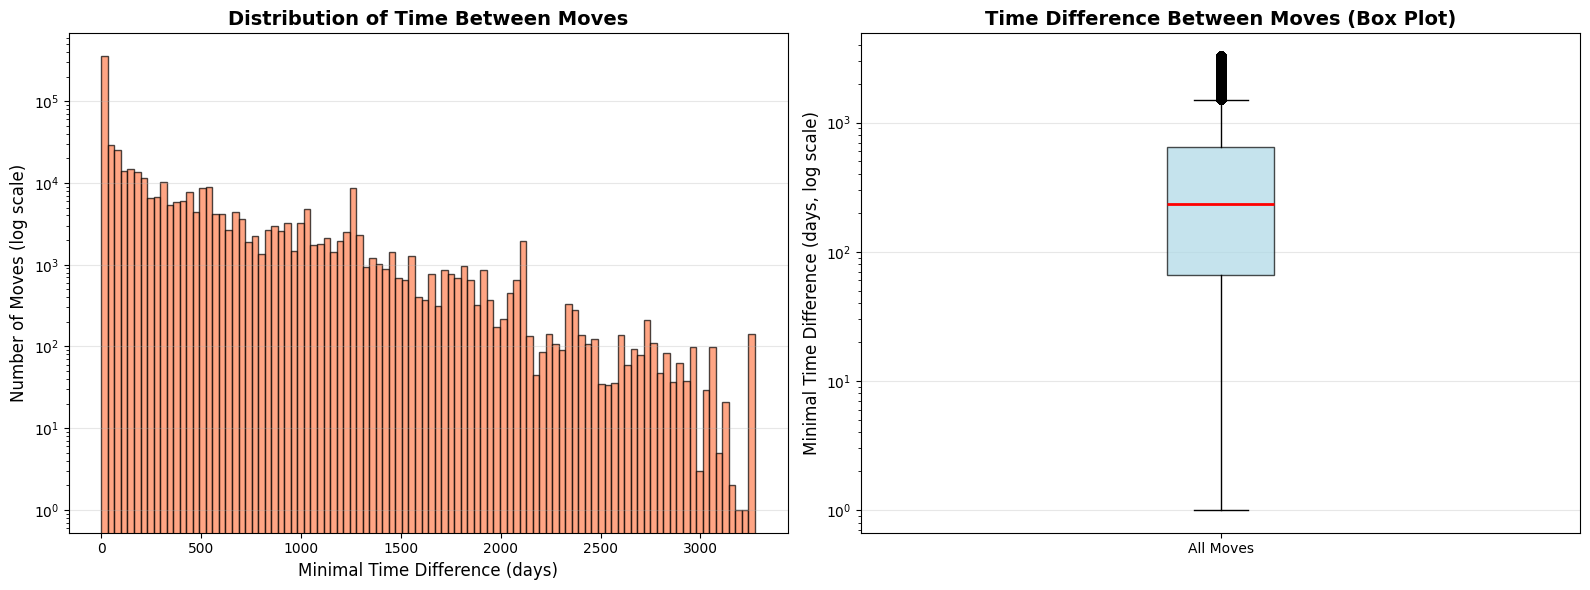

Time difference statistics:
  Mean: 229.70 days
  Median: 2.00 days
  Min: 0.00 days
  Max: 3273.00 days
  Std: 434.77 days


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

time_diffs_filtered = legit_moves['delta'].dropna()
ax1.hist(time_diffs_filtered, bins=100, alpha=0.7, color='coral', edgecolor='black')
ax1.set_xlabel('Minimal Time Difference (days)', fontsize=12)
ax1.set_ylabel('Number of Moves (log scale)', fontsize=12)
ax1.set_title('Distribution of Time Between Moves', fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

ax2.boxplot([time_diffs_filtered[time_diffs_filtered > 0]], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Minimal Time Difference (days, log scale)', fontsize=12)
ax2.set_title('Time Difference Between Moves (Box Plot)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(['All Moves'])

plt.tight_layout()
plt.show()

print(f"Time difference statistics:")
print(f"  Mean: {time_diffs_filtered.mean():.2f} days")
print(f"  Median: {time_diffs_filtered.median():.2f} days")
print(f"  Min: {time_diffs_filtered.min():.2f} days")
print(f"  Max: {time_diffs_filtered.max():.2f} days")
print(f"  Std: {time_diffs_filtered.std():.2f} days")

### 3.8 Time Between Moves by Platform

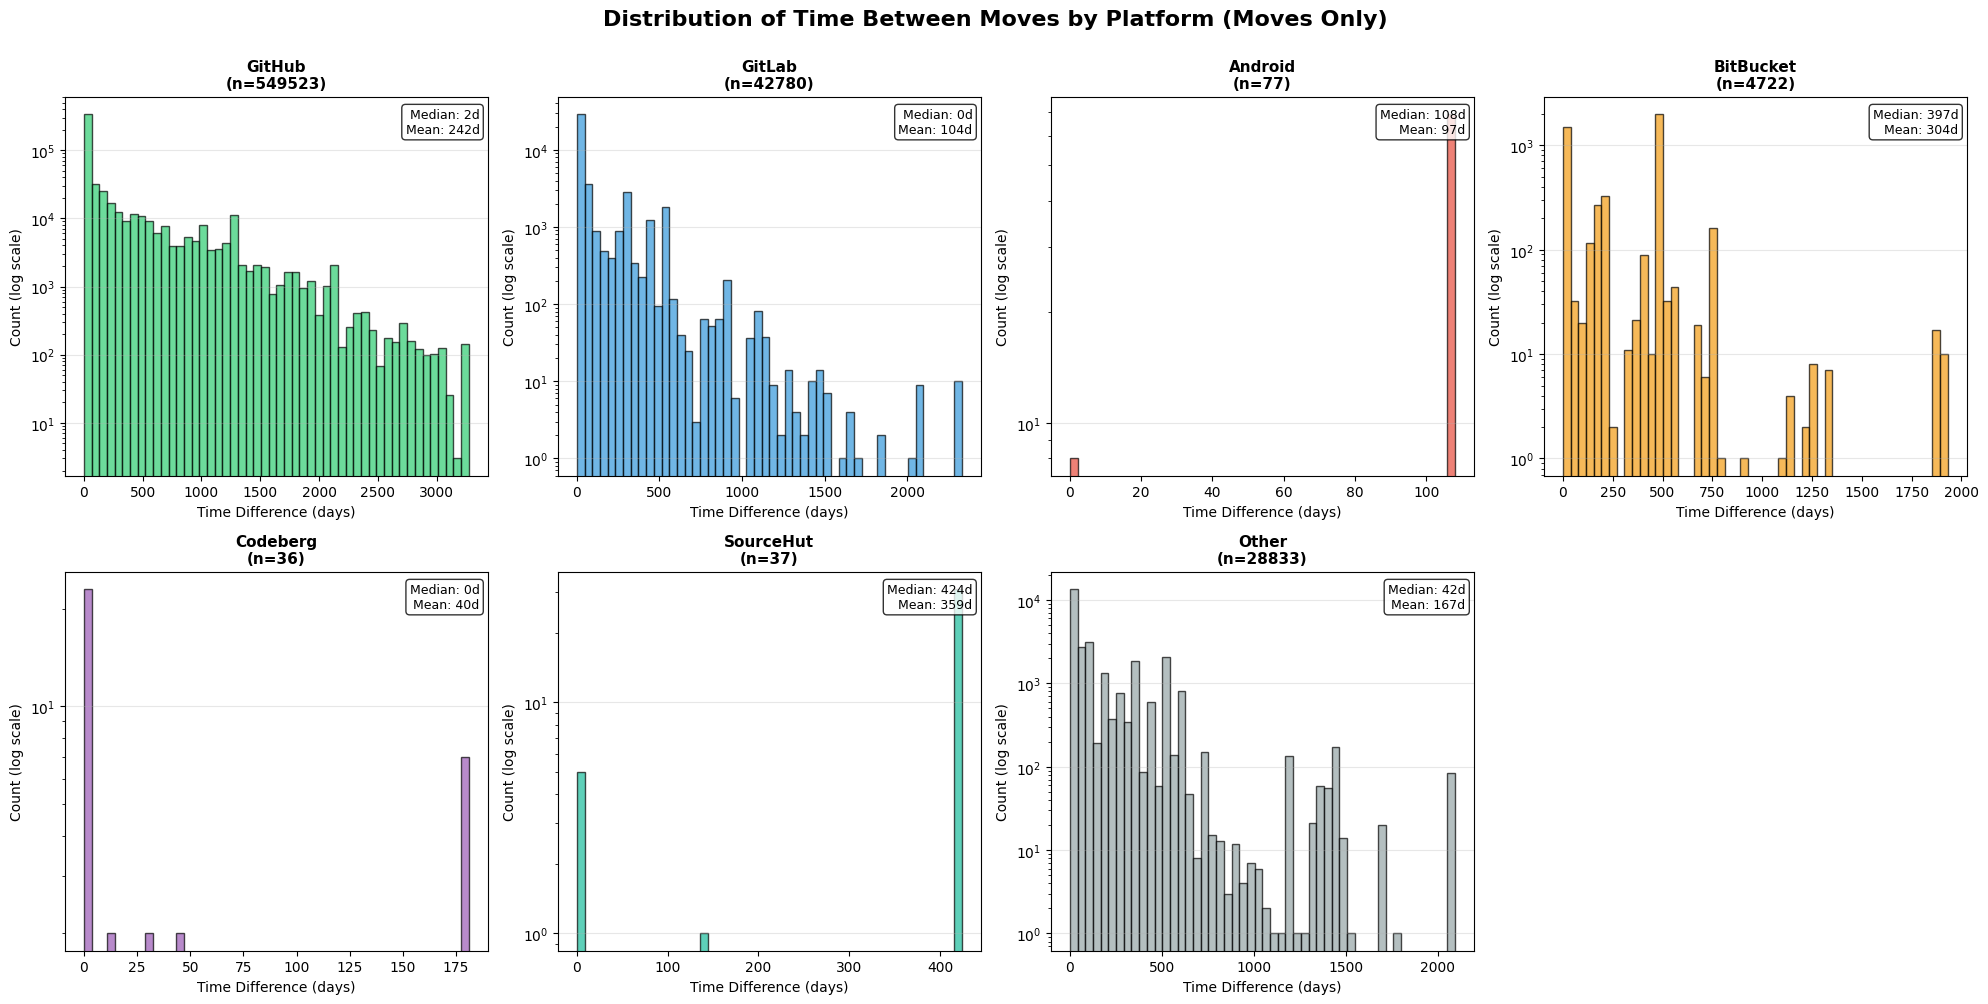

In [21]:
# Platform comparison - Time Between Moves Distribution (Alterations Only)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, platform in enumerate(platforms):
    platform_df = legit_moves[legit_moves['platform'] == platform]
    time_diffs = platform_df['delta'].dropna()
    
    if len(time_diffs) > 0:
        axes[i].hist(time_diffs, bins=50, alpha=0.7, color=colors[i], edgecolor='black')
        axes[i].set_xlabel('Time Difference (days)', fontsize=10)
        axes[i].set_ylabel('Count (log scale)', fontsize=10)
        axes[i].set_title(f'{platform}\n(n={len(time_diffs)})', fontsize=11, fontweight='bold')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        stats_text = f'Median: {time_diffs.median():.0f}d\nMean: {time_diffs.mean():.0f}d'
        axes[i].text(0.98, 0.97, stats_text, transform=axes[i].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'{platform}\n(n=0)', fontsize=11, fontweight='bold')

# Hide the last subplot
axes[7].axis('off')

plt.suptitle('Distribution of Time Between Moves by Platform (Moves Only)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.9 Unique Repository Count by Time Difference (Moves Only)

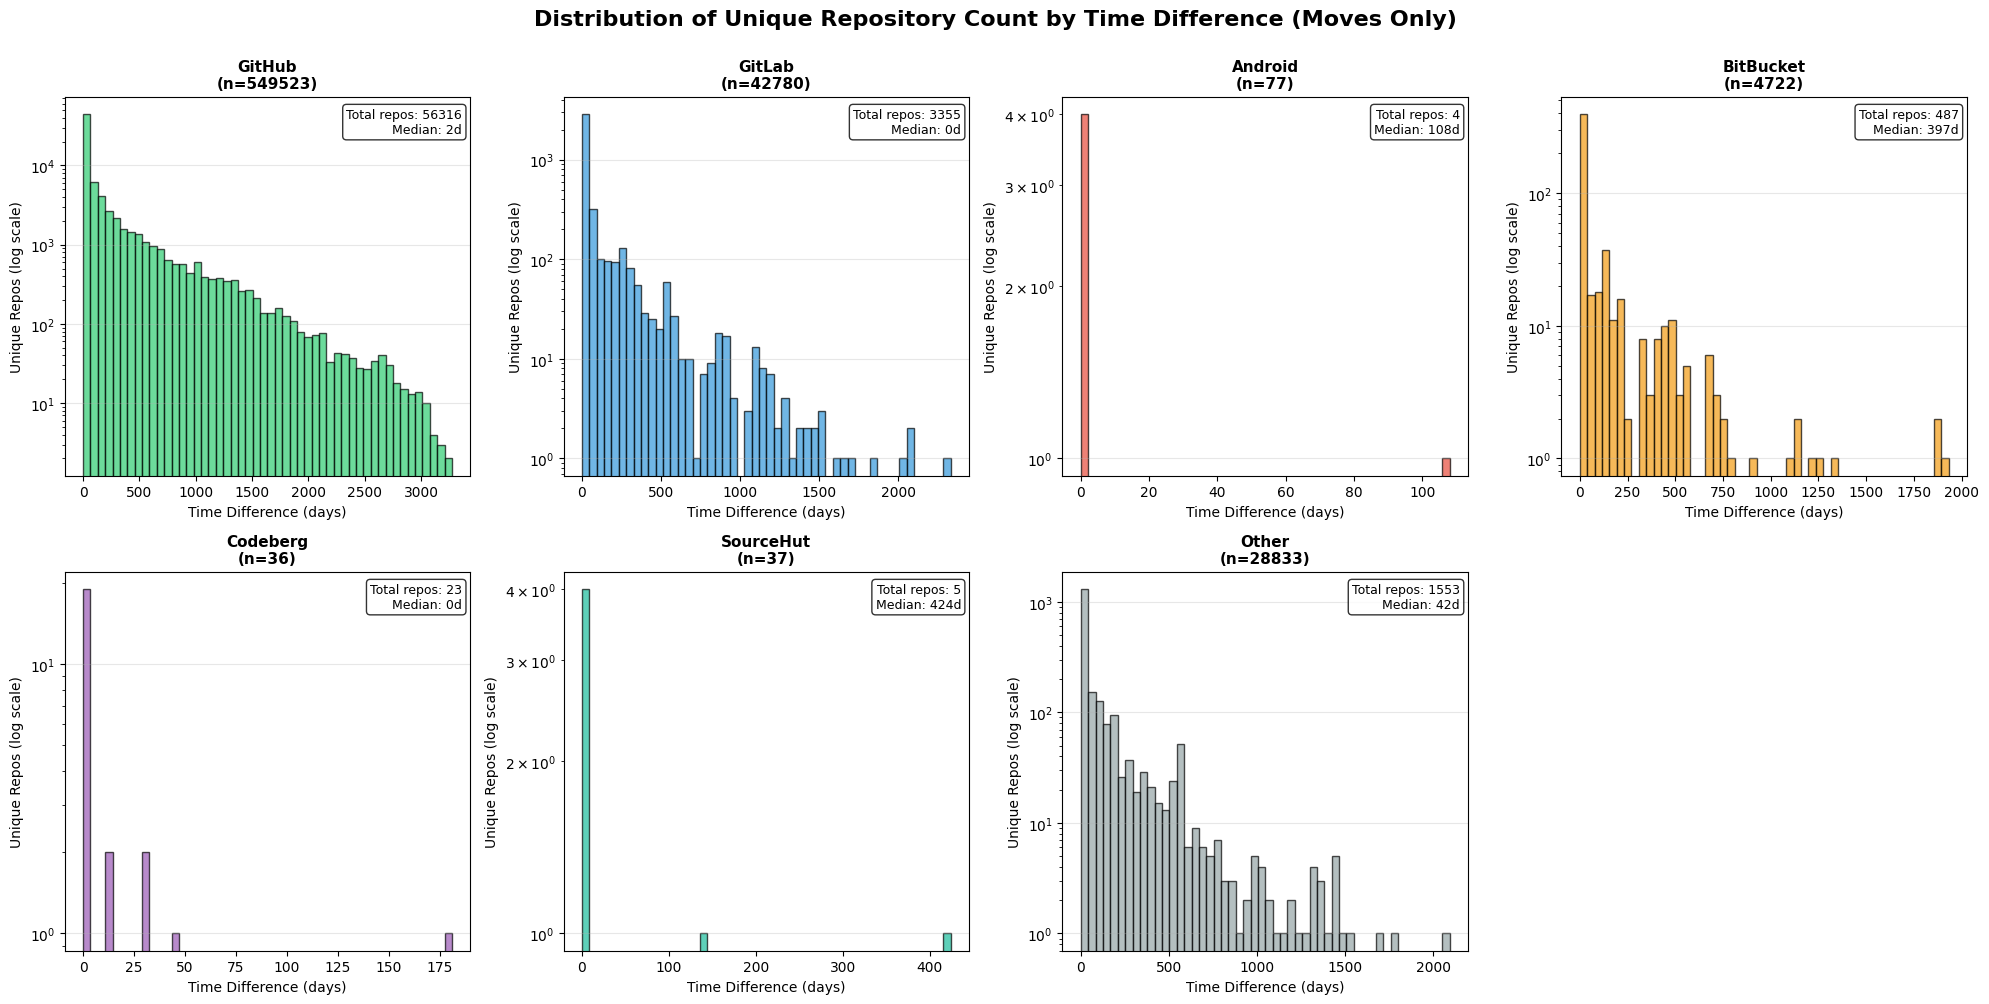

In [22]:
# Platform comparison - Unique Repository Count Distribution by Time (Moves Only)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, platform in enumerate(platforms):
    platform_df = legit_moves[legit_moves['platform'] == platform]
    
    if len(platform_df) > 0:
        # Group by delta bins and count unique repos
        time_diffs = platform_df['delta'].dropna()
        
        # Create histogram data for unique repos per time bin
        bins_edges = np.histogram_bin_edges(time_diffs, bins=50)
        platform_df_temp = platform_df.copy()
        platform_df_temp['delta_bin'] = pd.cut(platform_df_temp['delta'], bins=bins_edges, include_lowest=True)
        
        # Count unique repos per bin
        unique_repos_per_bin = platform_df_temp.groupby('delta_bin', observed=True)['origin_url'].nunique()
        
        # Get bin centers and widths for plotting
        bin_centers = [(b.left + b.right) / 2 for b in unique_repos_per_bin.index]
        bin_widths = [b.right - b.left for b in unique_repos_per_bin.index]
        
        axes[i].bar(bin_centers, unique_repos_per_bin.values, 
                   width=bin_widths, alpha=0.7, color=colors[i], edgecolor='black')
        axes[i].set_xlabel('Time Difference (days)', fontsize=10)
        axes[i].set_ylabel('Unique Repos (log scale)', fontsize=10)
        axes[i].set_title(f'{platform}\n(n={len(platform_df)})', fontsize=11, fontweight='bold')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        total_unique_repos = platform_df['origin_url'].nunique()
        stats_text = f'Total repos: {total_unique_repos}\nMedian: {time_diffs.median():.0f}d'
        axes[i].text(0.98, 0.97, stats_text, transform=axes[i].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'{platform}\n(n=0)', fontsize=11, fontweight='bold')

# Hide the last subplot
axes[7].axis('off')

plt.suptitle('Distribution of Unique Repository Count by Time Difference (Moves Only)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.10 Distribution of Time Between Old and New Revisions (Moves Only)

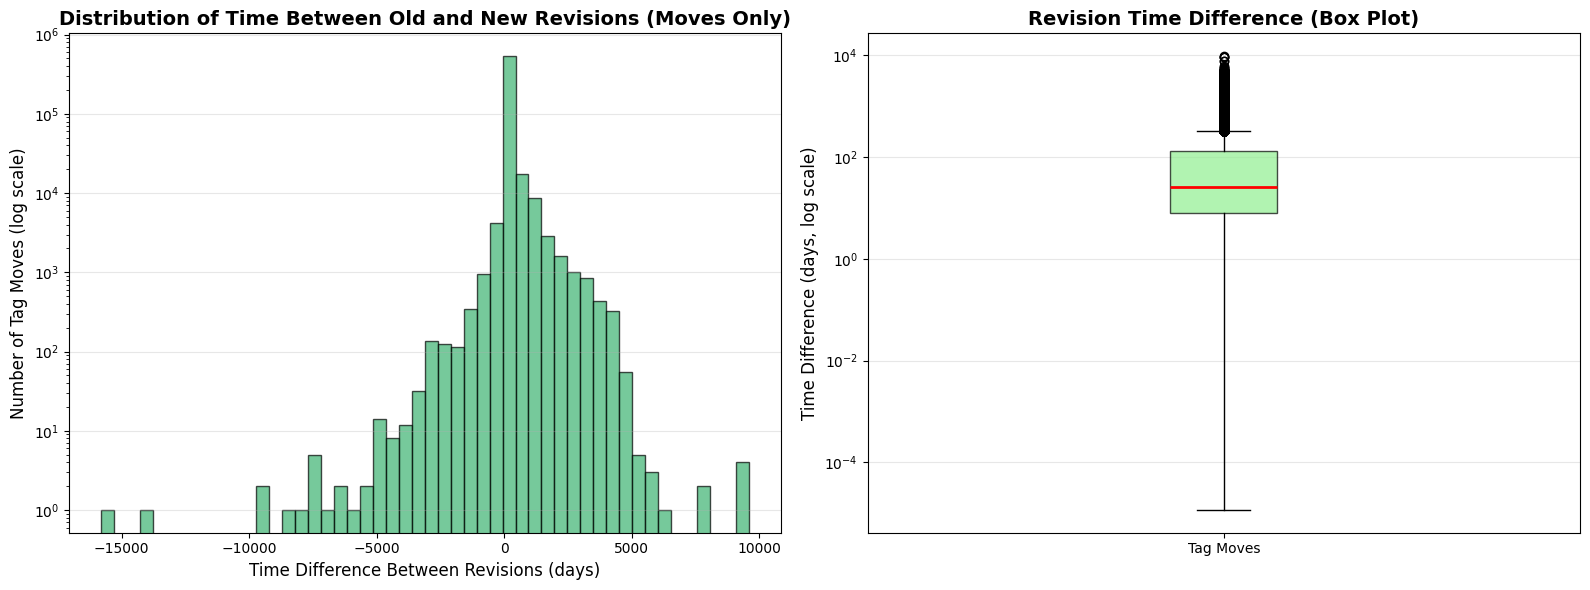

Revision time difference statistics (for 626008 moves):
  Mean: 86.21 days
  Median: 0.00 days
  Min: -15807.67 days
  Max: 9583.97 days
  Std: 346.36 days
  Negative values (new revision older than old): 24542


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

rev_time_diffs = legit_moves['rev_time_diff_days'].dropna()
ax1.hist(rev_time_diffs, bins=50, alpha=0.7, color='mediumseagreen', edgecolor='black')
ax1.set_xlabel('Time Difference Between Revisions (days)', fontsize=12)
ax1.set_ylabel('Number of Tag Moves (log scale)', fontsize=12)
ax1.set_title('Distribution of Time Between Old and New Revisions (Moves Only)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_yscale('log')

positive_rev_diffs = rev_time_diffs[rev_time_diffs > 0]
if len(positive_rev_diffs) > 0:
    ax2.boxplot([positive_rev_diffs], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
    ax2.set_ylabel('Time Difference (days, log scale)', fontsize=12)
    ax2.set_title('Revision Time Difference (Box Plot)', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticklabels(['Tag Moves'])

plt.tight_layout()
plt.show()

print(f"Revision time difference statistics (for {len(legit_moves)} moves):")
print(f"  Mean: {rev_time_diffs.mean():.2f} days")
print(f"  Median: {rev_time_diffs.median():.2f} days")
print(f"  Min: {rev_time_diffs.min():.2f} days")
print(f"  Max: {rev_time_diffs.max():.2f} days")
print(f"  Std: {rev_time_diffs.std():.2f} days")
print(f"  Negative values (new revision older than old): {len(rev_time_diffs[rev_time_diffs < 0])}")

### 3.11 Revision Time Differences by Platform (Moves Only)

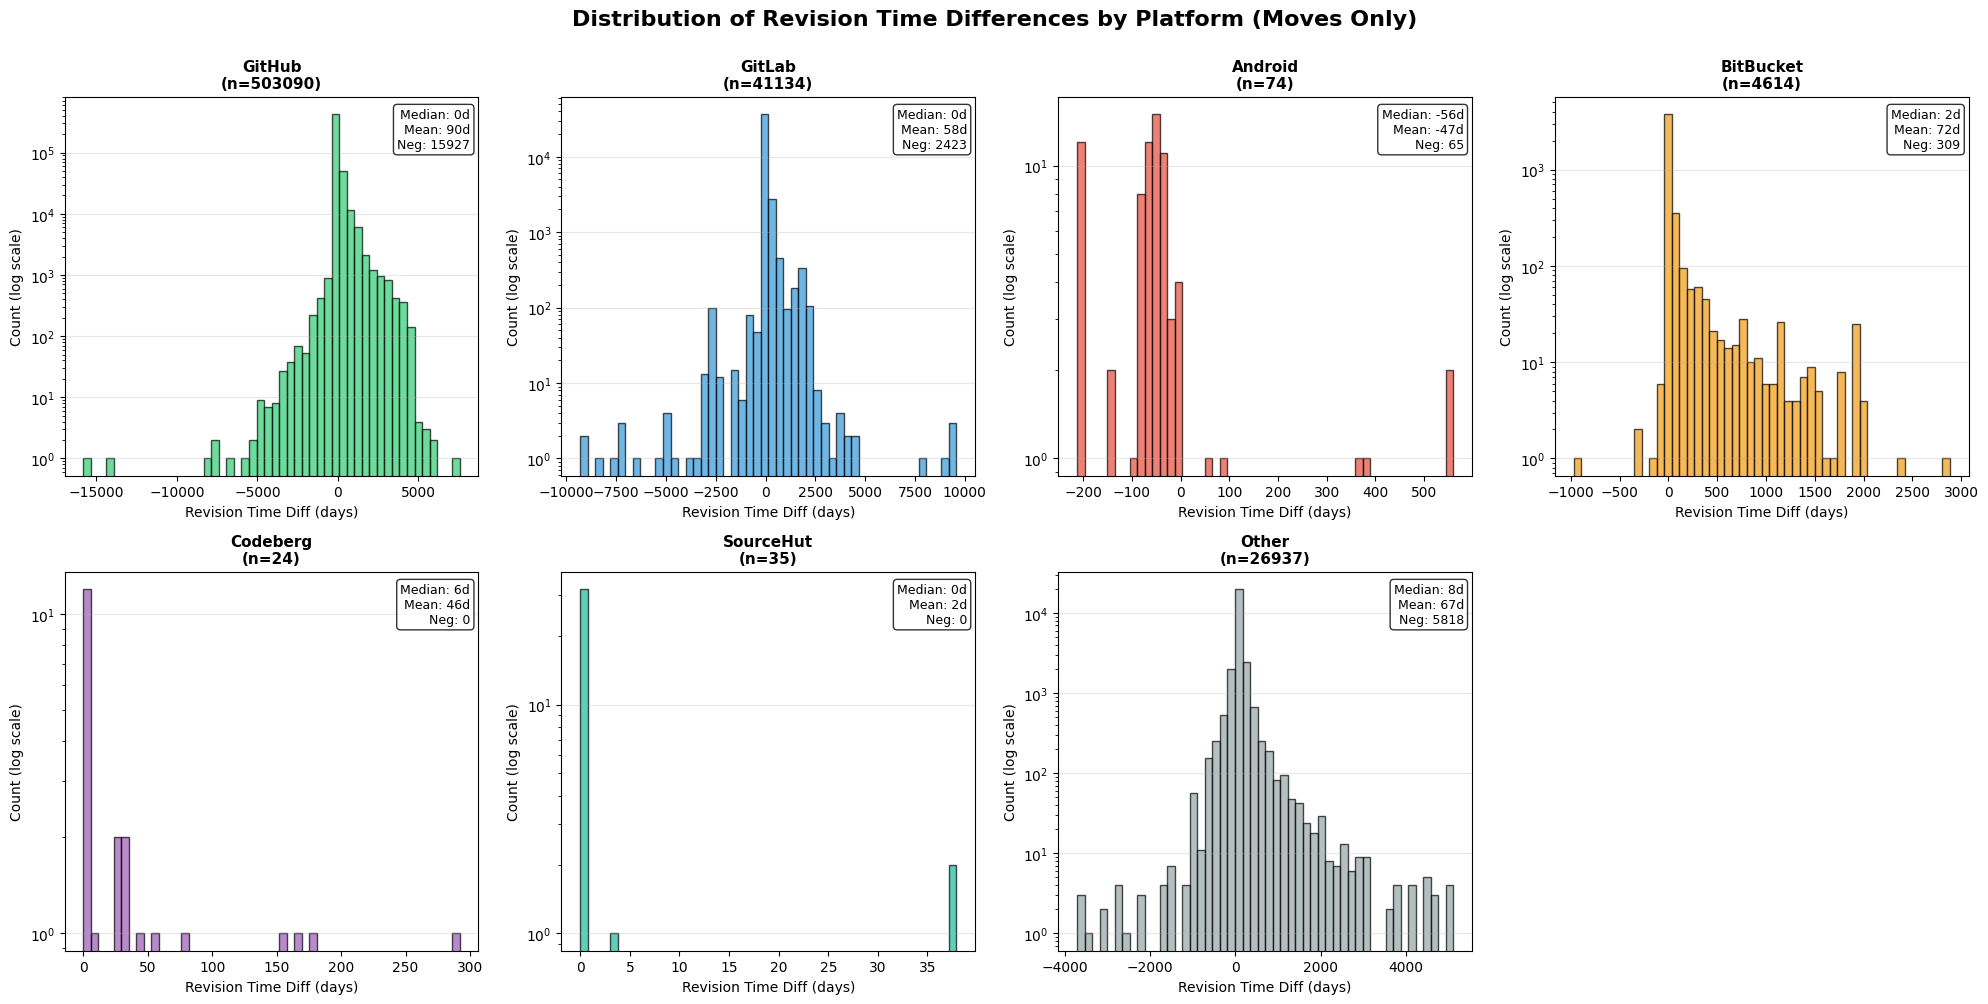

In [26]:
# Platform comparison - Revision Time Difference Distribution (Alterations Only)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, platform in enumerate(platforms):
    platform_df = legit_moves[legit_moves['platform'] == platform]
    rev_time_diffs = platform_df['rev_time_diff_days'].dropna()
    
    if len(rev_time_diffs) > 0:
        axes[i].hist(rev_time_diffs, bins=50, alpha=0.7, color=colors[i], edgecolor='black')
        axes[i].set_xlabel('Revision Time Diff (days)', fontsize=10)
        axes[i].set_ylabel('Count (log scale)', fontsize=10)
        axes[i].set_title(f'{platform}\n(n={len(rev_time_diffs)})', fontsize=11, fontweight='bold')
        axes[i].set_yscale('log')
        axes[i].grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        negative_count = len(rev_time_diffs[rev_time_diffs < 0])
        stats_text = f'Median: {rev_time_diffs.median():.0f}d\nMean: {rev_time_diffs.mean():.0f}d\nNeg: {negative_count}'
        axes[i].text(0.98, 0.97, stats_text, transform=axes[i].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].set_title(f'{platform}\n(n=0)', fontsize=11, fontweight='bold')

# Hide the last subplot
axes[7].axis('off')

plt.suptitle('Distribution of Revision Time Differences by Platform (Moves Only)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.12 Tag Moves vs Deletions Over Time

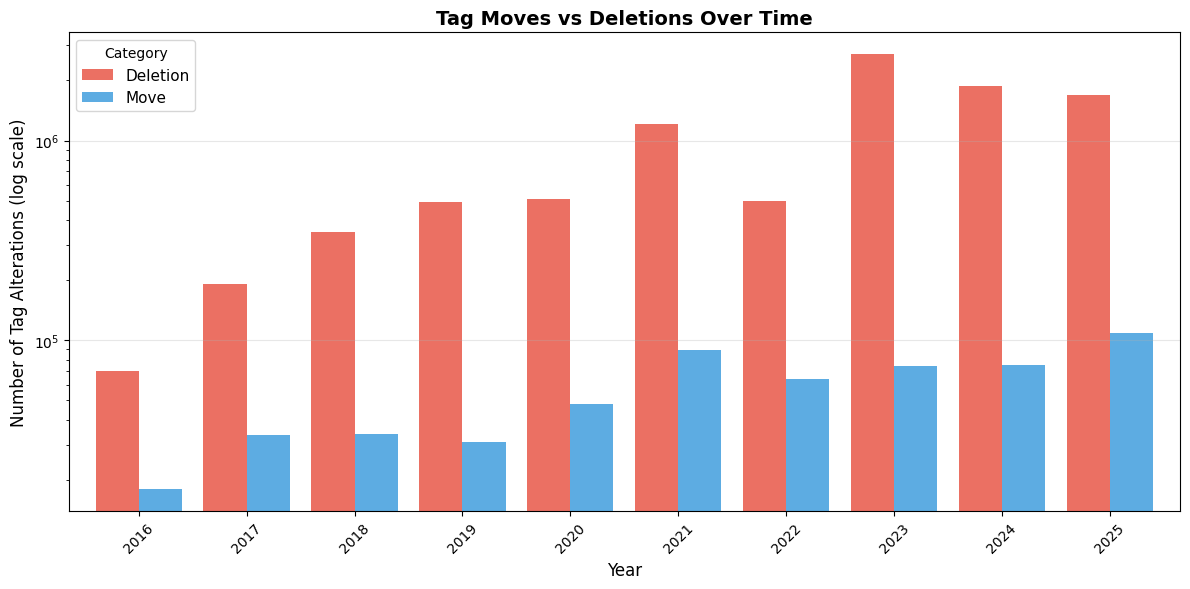


Yearly breakdown:
category   Deletion    Move
snap_year                  
2016          70501   17954
2017         192010   33635
2018         349915   33848
2019         493424   30830
2020         508706   47851
2021        1215443   89576
2022         495744   63919
2023        2710720   74311
2024        1876821   74906
2025        1681854  109078


In [32]:
inconsistencies_by_year_type = df.groupby(['snap_year', 'category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

inconsistencies_by_year_type.plot(kind='bar', ax=ax, 
                                   color=['#e74c3c', '#3498db'], alpha=0.8, width=0.8)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Tag Alterations (log scale)', fontsize=12)
ax.set_title('Tag Moves vs Deletions Over Time', fontsize=14, fontweight='bold')
ax.legend(title='Category', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("\nYearly breakdown:")
print(inconsistencies_by_year_type)

### 3.13 Moves vs Deletions by Platform

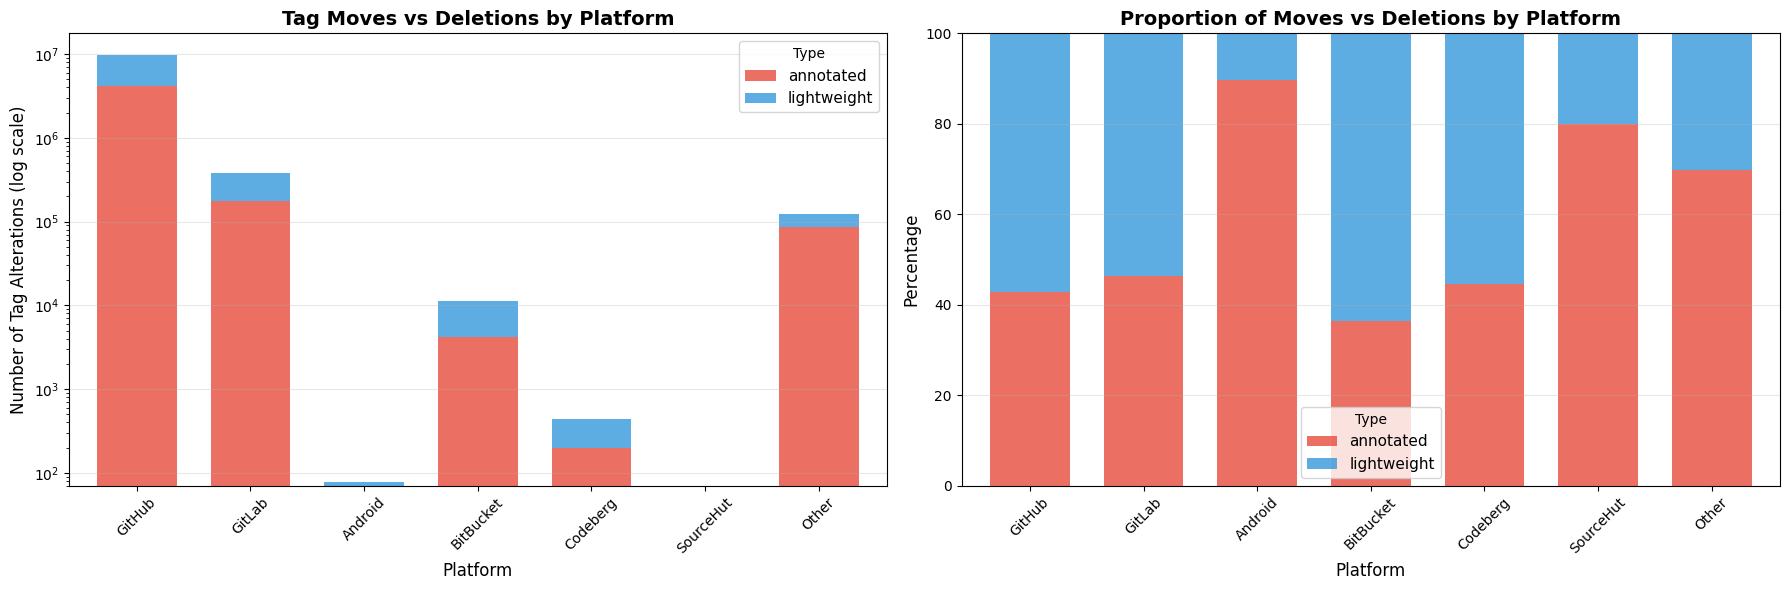


Breakdown by platform:
type       annotated  lightweight
platform                         
GitHub       4144348      5511377
GitLab        175375       203621
Android           70            8
BitBucket       4159         7232
Codeberg         197          244
SourceHut         52           13
Other          86695        37655

Percentages:
type       annotated  lightweight
platform                         
GitHub          42.9         57.1
GitLab          46.3         53.7
Android         89.7         10.3
BitBucket       36.5         63.5
Codeberg        44.7         55.3
SourceHut       80.0         20.0
Other           69.7         30.3


In [28]:
# Platform comparison - Alterations vs Deletions by Platform
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Count by platform and type
platform_type_counts = df.groupby(['platform', 'type']).size().unstack(fill_value=0)
platform_type_counts = platform_type_counts.reindex(index=platforms, fill_value=0)

# Stacked bar chart
platform_type_counts.plot(kind='bar', stacked=True, ax=ax1, 
                          color=['#e74c3c', '#3498db'], alpha=0.8, width=0.7)
ax1.set_xlabel('Platform', fontsize=12)
ax1.set_ylabel('Number of Tag Alterations (log scale)', fontsize=12)
ax1.set_title('Tag Moves vs Deletions by Platform', fontsize=14, fontweight='bold')
ax1.legend(title='Type', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)
ax1.set_yscale('log')

# Proportion chart
platform_type_pct = platform_type_counts.div(platform_type_counts.sum(axis=1), axis=0) * 100
platform_type_pct.plot(kind='bar', stacked=True, ax=ax2, 
                       color=['#e74c3c', '#3498db'], alpha=0.8, width=0.7)
ax2.set_xlabel('Platform', fontsize=12)
ax2.set_ylabel('Percentage', fontsize=12)
ax2.set_title('Proportion of Moves vs Deletions by Platform', fontsize=14, fontweight='bold')
ax2.legend(title='Type', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\nBreakdown by platform:")
print(platform_type_counts)
print("\nPercentages:")
print(platform_type_pct.round(1))

### 3.14 Repository Count vs Alteration Count by Time Difference (Dual-Axis)

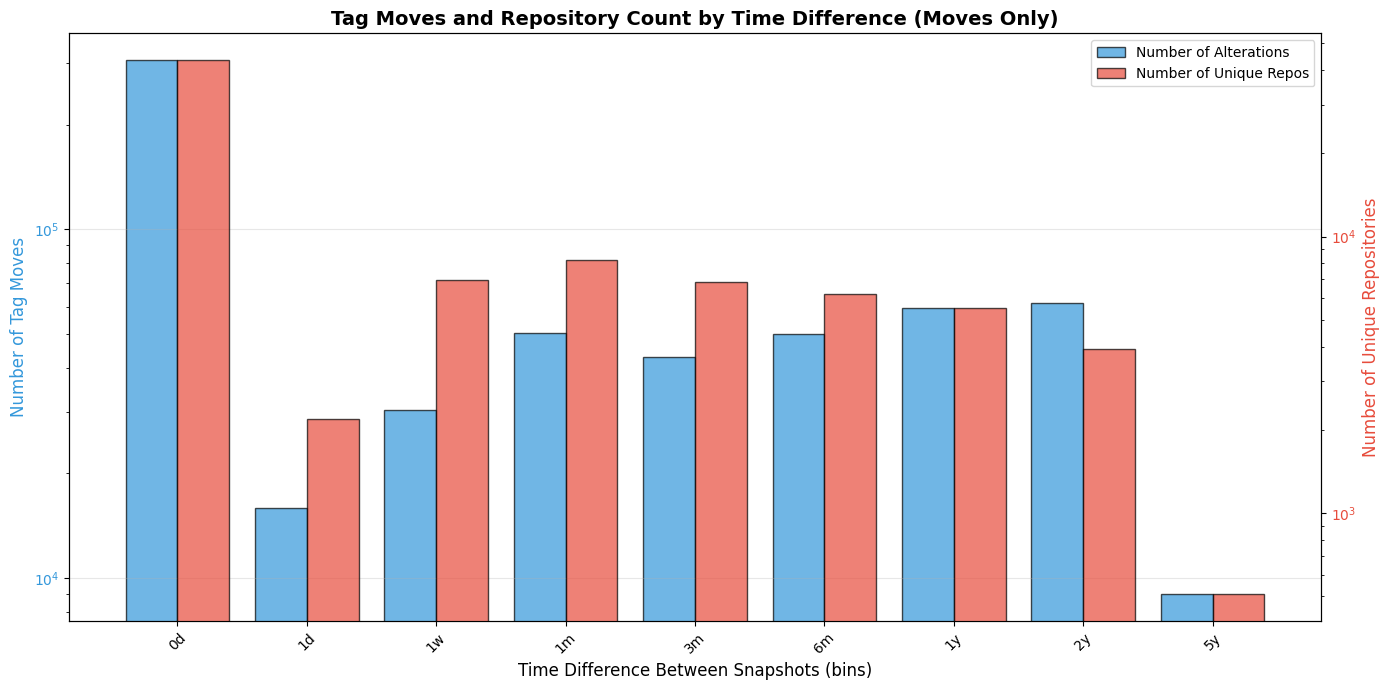

Tag moves and repository distribution by time difference bin:
           Alterations  Unique Repos  Avg Alterations per Repo
delta_bin                                                     
0d              306250         43447                      7.05
1d               15813          2185                      7.24
1w               30265          6985                      4.33
1m               50505          8229                      6.14
3m               43100          6856                      6.29
6m               50197          6217                      8.07
1y               59311          5505                     10.77
2y               61597          3915                     15.73
5y                8970           509                     17.62

Total tag moves analyzed: 626_008
Total unique repositories: 61_743


In [29]:
# Repository count vs Alteration count by Time Difference (Dual-axis plot)
# Bin the delta values
bins = [0, 1, 7, 30, 90, 180, 365, 730, 1825, 3650, float('inf')]
bin_labels = ['0d', '1d', '1w', '1m', '3m', '6m', '1y', '2y', '5y', '10y+']

legit_moves_binned = legit_moves.copy()
legit_moves_binned['delta_bin'] = pd.cut(legit_moves_binned['delta'], bins=bins, labels=bin_labels, right=False)

# Count alterations and unique repos per bin
alterations_per_bin = legit_moves_binned.groupby('delta_bin', observed=True).size()
repos_per_bin = legit_moves_binned.groupby('delta_bin', observed=True)['origin_url'].nunique()

fig, ax1 = plt.subplots(figsize=(14, 7))

x_pos = np.arange(len(alterations_per_bin))

# Plot alterations on left y-axis
color1 = '#3498db'
bars1 = ax1.bar(x_pos - 0.2, alterations_per_bin.values, width=0.4, alpha=0.7, 
                color=color1, label='Number of Alterations', edgecolor='black')
ax1.set_xlabel('Time Difference Between Snapshots (bins)', fontsize=12)
ax1.set_ylabel('Number of Tag Moves', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

# Plot repos on right y-axis
ax2 = ax1.twinx()
color2 = '#e74c3c'
bars2 = ax2.bar(x_pos + 0.2, repos_per_bin.values, width=0.4, alpha=0.7, 
                color=color2, label='Number of Unique Repos', edgecolor='black')
ax2.set_ylabel('Number of Unique Repositories', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_yscale('log')

# Set x-axis
ax1.set_xticks(x_pos)
ax1.set_xticklabels(alterations_per_bin.index, rotation=45)
ax1.set_title('Tag Moves and Repository Count by Time Difference (Moves Only)', 
              fontsize=14, fontweight='bold')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("Tag moves and repository distribution by time difference bin:")
summary_df = pd.DataFrame({
    'Alterations': alterations_per_bin,
    'Unique Repos': repos_per_bin,
    'Avg Alterations per Repo': (alterations_per_bin / repos_per_bin).round(2)
})
print(summary_df)
print(f"\nTotal tag moves analyzed: {len(legit_moves):_}")
print(f"Total unique repositories: {legit_moves['origin_url'].nunique():_}")

### 3.15 Repository Count vs Alteration Count — Scatter and Average per Bin

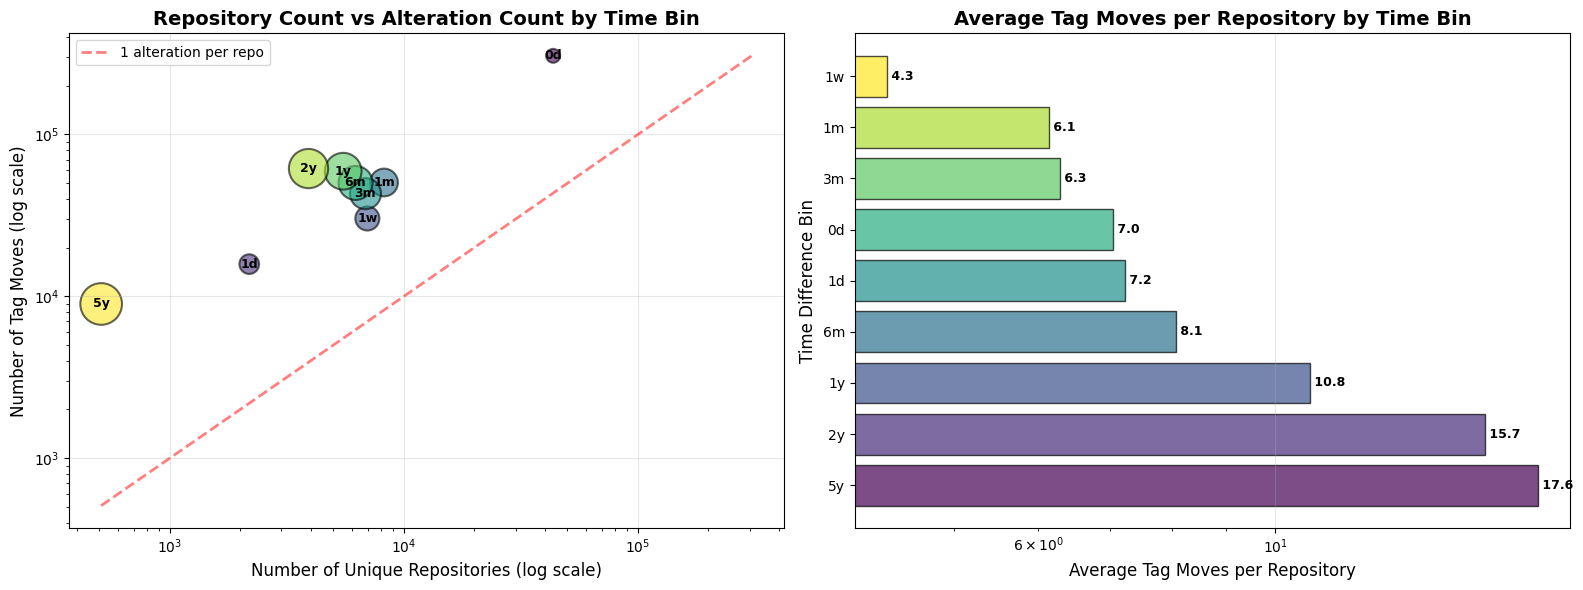


Key insights:
Bins with highest concentration (most alterations per repo):
delta_bin
5y    17.622790
2y    15.733589
1y    10.774024
dtype: float64

Bins with widest distribution (most repos involved):
delta_bin
0d    43447
1m     8229
1w     6985
Name: origin_url, dtype: int64


In [30]:
# Repository count vs Alteration count scatter plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: alterations vs repos per bin
scatter_sizes = [100 * (i + 1) for i in range(len(alterations_per_bin))]
scatter = ax1.scatter(repos_per_bin.values, alterations_per_bin.values, 
                      s=scatter_sizes, alpha=0.6, c=range(len(alterations_per_bin)), 
                      cmap='viridis', edgecolors='black', linewidth=1.5)

# Add bin labels to points
for i, (x, y, label) in enumerate(zip(repos_per_bin.values, alterations_per_bin.values, bin_labels)):
    ax1.annotate(label, (x, y), fontsize=9, ha='center', va='center', fontweight='bold')

ax1.set_xlabel('Number of Unique Repositories (log scale)', fontsize=12)
ax1.set_ylabel('Number of Tag Moves (log scale)', fontsize=12)
ax1.set_title('Repository Count vs Alteration Count by Time Bin', fontsize=14, fontweight='bold')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Add diagonal reference line (y=x)
min_val = min(repos_per_bin.min(), alterations_per_bin.min())
max_val = max(repos_per_bin.max(), alterations_per_bin.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, linewidth=2, 
         label='1 alteration per repo')
ax1.legend(fontsize=10)

# Bar chart showing average alterations per repo
avg_per_repo = (alterations_per_bin / repos_per_bin).sort_values(ascending=False)
colors_sorted = plt.cm.viridis(np.linspace(0, 1, len(avg_per_repo)))

bars = ax2.barh(range(len(avg_per_repo)), avg_per_repo.values, alpha=0.7, 
                color=colors_sorted, edgecolor='black')
ax2.set_yticks(range(len(avg_per_repo)))
ax2.set_yticklabels(avg_per_repo.index)
ax2.set_xlabel('Average Tag Moves per Repository', fontsize=12)
ax2.set_ylabel('Time Difference Bin', fontsize=12)
ax2.set_title('Average Tag Moves per Repository by Time Bin', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (idx, val) in enumerate(avg_per_repo.items()):
    ax2.text(val, i, f' {val:.1f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey insights:")
print(f"Bins with highest concentration (most alterations per repo):")
print(avg_per_repo.head(3))
print(f"\nBins with widest distribution (most repos involved):")
print(repos_per_bin.sort_values(ascending=False).head(3))

### 3.16 3D Surface Plot — Delta Days × Unique Repos × Alteration Count

/tmp/ipykernel_4020140/2041522162.py:42: UserWarning: Attempt to set non-positive zlim on a log-scaled axis will be ignored.
  ax.set_zscale('log')


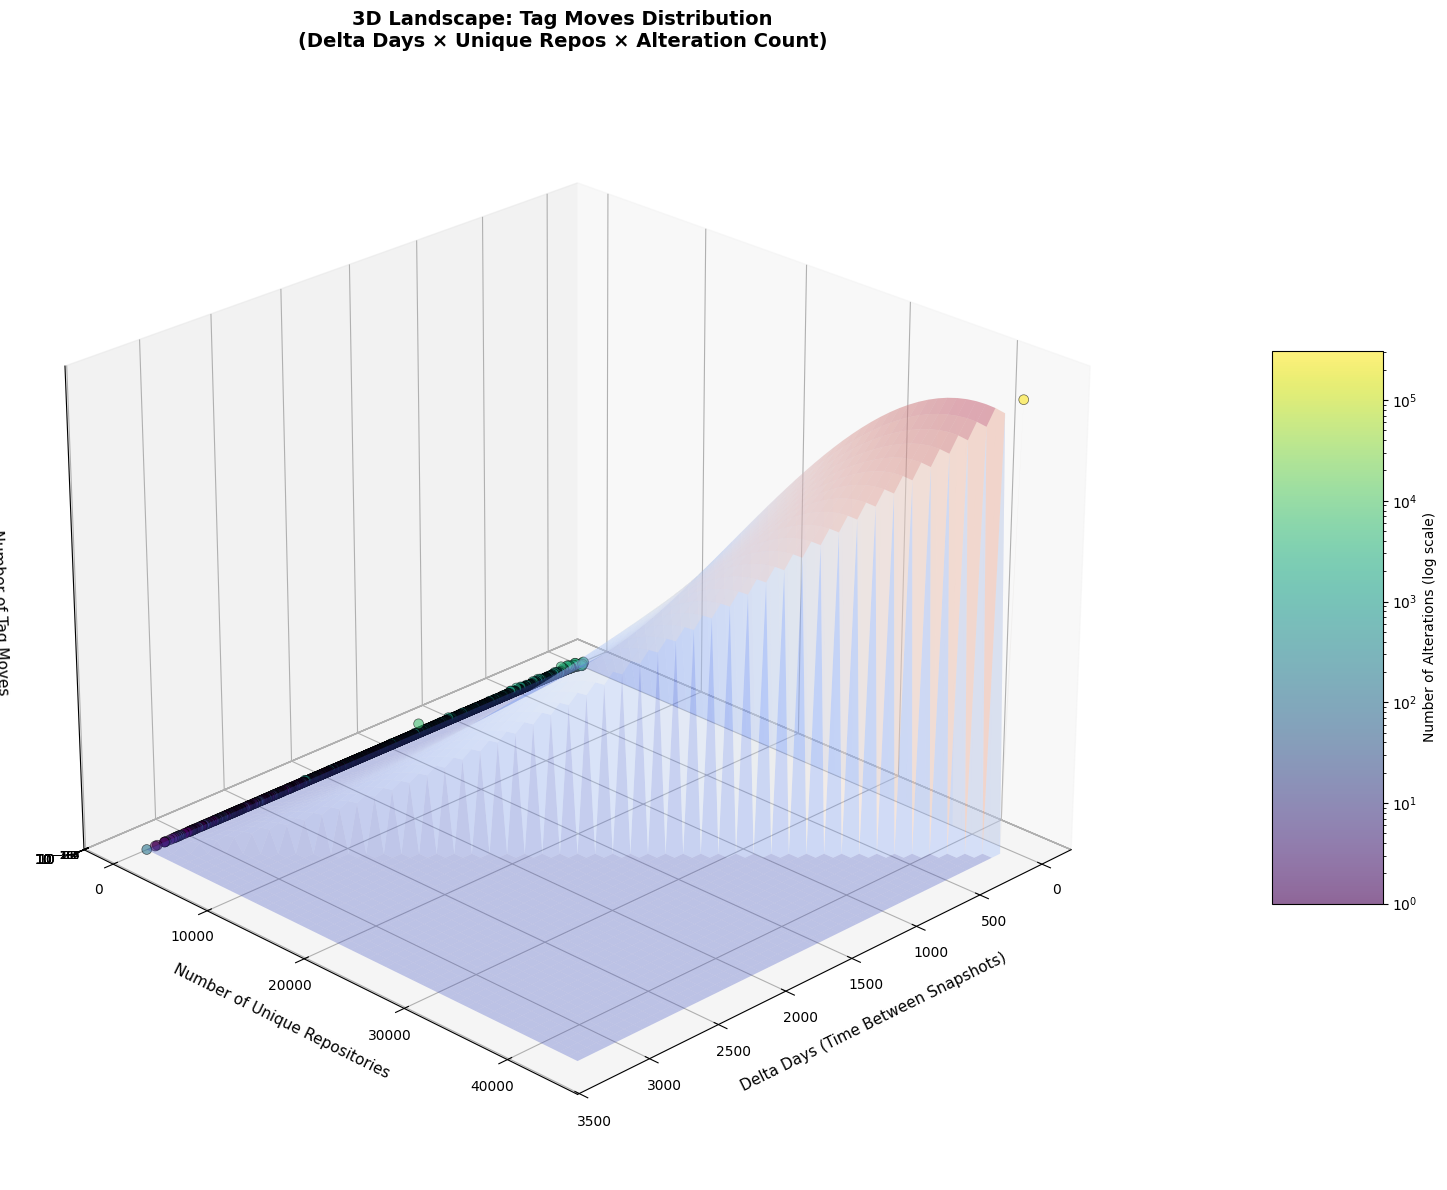

3D plot statistics:
  Delta range: 0 to 3273 days
  Unique repos range: 1 to 43447
  Alteration count range: 1 to 306250
  Total data points plotted: 2373

Peak 'mountains' (highest alteration counts):
  Delta=0d, Repos=43447, Alterations=306250
  Delta=1256d, Repos=9, Alterations=6461
  Delta=140d, Repos=101, Alterations=3958
  Delta=2d, Repos=650, Alterations=3741
  Delta=42d, Repos=286, Alterations=3300


In [31]:
# 3D Surface Plot: Delta Days x Unique Repos x Alteration Count
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Prepare data - aggregate by delta value to get unique repo count and alteration count
delta_groups = legit_moves.groupby('delta').agg({
    'origin_url': 'nunique',  # unique repos
    'tag_name': 'count'       # alteration count
}).reset_index()
delta_groups.columns = ['delta', 'unique_repos', 'alteration_count']

# Filter out extreme outliers for better visualization
delta_groups_filtered = delta_groups[delta_groups['delta'] <= 3650]  # Up to 10 years

x = delta_groups_filtered['delta'].values
y = delta_groups_filtered['unique_repos'].values
z = delta_groups_filtered['alteration_count'].values

# Create color map based on alteration count
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=50, alpha=0.6, 
                     edgecolors='black', linewidth=0.5, norm=plt.matplotlib.colors.LogNorm())

# Create a meshgrid for surface interpolation
xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(y.min(), y.max(), 50)
xi_grid, yi_grid = np.meshgrid(xi, yi)

zi_grid = griddata((x, y), z, (xi_grid, yi_grid), method='cubic', fill_value=0)
zi_grid = np.maximum(zi_grid, 0)

surf = ax.plot_surface(xi_grid, yi_grid, zi_grid, cmap='coolwarm', alpha=0.3, 
                       edgecolor='none', antialiased=True)

ax.set_xlabel('Delta Days (Time Between Snapshots)', fontsize=11, labelpad=10)
ax.set_ylabel('Number of Unique Repositories', fontsize=11, labelpad=10)
ax.set_zlabel('Number of Tag Moves', fontsize=11, labelpad=10)
ax.set_title('3D Landscape: Tag Moves Distribution\n(Delta Days × Unique Repos × Alteration Count)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_zscale('log')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5, pad=0.1)
cbar.set_label('Number of Alterations (log scale)', fontsize=10)

ax.view_init(elev=25, azim=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"3D plot statistics:")
print(f"  Delta range: {x.min():.0f} to {x.max():.0f} days")
print(f"  Unique repos range: {y.min()} to {y.max()}")
print(f"  Alteration count range: {z.min()} to {z.max()}")
print(f"  Total data points plotted: {len(x)}")
print(f"\nPeak 'mountains' (highest alteration counts):")
top_peaks = delta_groups_filtered.nlargest(5, 'alteration_count')
for idx, row in top_peaks.iterrows():
    print(f"  Delta={row['delta']:.0f}d, Repos={row['unique_repos']}, Alterations={row['alteration_count']}")